# Environment Setup

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("fashion-mnist_train.csv")

print(df.shape)     
print(df.head())

(60000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0      

### for knowing shape of labels and pixels

In [5]:
# separating label from pixels

labels = df.iloc[:, 0].values          
pixels = df.iloc[:, 1:].values         

print("Labels shape:", labels.shape)
print("Pixels shape:", pixels.shape)

Labels shape: (60000,)
Pixels shape: (60000, 784)


### normalizing pixels that contain values from 0-255 into 0-1 range

In [6]:
pixels_normalized = pixels.astype("float32") / 255.0

print("Min value:", pixels.min())   # will be 0
print("Max value:", pixels.max())   # will be 255

print("Min value:", pixels_normalized.min())   # will be 0
print("Max value:", pixels_normalized.max())   # will be 1

Min value: 0
Max value: 255
Min value: 0.0
Max value: 1.0


## the original dataset remains same as i made new pixel array that contains the normalized values

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## pixels vs normalized pixels difference

In [8]:
print(pixels[0][:100])              # raw values like 30, 33, 0, 255
print(pixels_normalized[0][:100])    # normalized values between 0 and 1

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0 62 61
 21 29 23 51]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         

## spliting training data into a training set and a validation set using an 80/20 ratio

In [10]:
from sklearn.model_selection import train_test_split

# Spliting pixels_normalized and labels
X_train, X_val, y_train, y_val = train_test_split(pixels_normalized,   labels, test_size=0.2,  random_state=42 ) #test size=0.2 shows that training set=80% and test set=20%

## shape of train and validate split

In [11]:
# checking the split shape to verify 
print("X_train shape:", X_train.shape)   # 80% of image
print("X_val shape:", X_val.shape)       # 20% of image
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (48000, 784)
X_val shape: (12000, 784)
y_train shape: (48000,)
y_val shape: (12000,)


## class distribution

In [12]:
import pandas as pd

print("Class distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution in validation set:")
print(pd.Series(y_val).value_counts().sort_index())

Class distribution in training set:
0    4768
1    4826
2    4800
3    4758
4    4815
5    4859
6    4757
7    4776
8    4851
9    4790
Name: count, dtype: int64

Class distribution in validation set:
0    1232
1    1174
2    1200
3    1242
4    1185
5    1141
6    1243
7    1224
8    1149
9    1210
Name: count, dtype: int64


# Part 1: Backpropagation From Scratch

## creating a subset of 5000 samples for training

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  #for reproducability of results

X = pixels_normalized[:5000]
y_labels = labels[:5000]


Y = np.eye(10)[y_labels] # converting labels into their corresponding 10-dimensional onehot encoding.

#np.eye creates an indentity array againt each label that are 0-9 e.g if label is 2 the array will be [0 0 1 0 0 0 0 0 0 0] 


print(X.shape)
print(Y.shape)

(5000, 784)
(5000, 10)


## initializing weights

In [14]:
input_size = 784
hidden_size = 64
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros(output_size)

## saving copy of weights for gradiant check

In [15]:
W1_start = W1
b1_start = b1
W2_start = W2
b2_start = b2

## forward,backward pass, loss(cross-entropy), hidden layer(ReLu), output layer(Softmax)
## manually

In [16]:
learning_rate = 0.5
epochs = 20
losses = []

# Variables to store the very first (forward/backward) gradients for verification
dW1_first, db1_first, dW2_first, db2_first = None, None, None, None

for epoch in range(epochs):
    # forward pass
    hidden_input = X @ W1 + b1
    hidden_output = np.maximum(0, hidden_input)   # ReLU

    output_input = hidden_output @ W2 + b2
    output_input_shifted = output_input - np.max(output_input, axis=1, keepdims=True)
    exp_values = np.exp(output_input_shifted)
    predictions = exp_values / np.sum(exp_values, axis=1, keepdims=True)   # softmax

    # loss: cross entropy
    loss = -np.mean(np.sum(Y * np.log(predictions + 1e-12), axis=1))
    losses.append(loss)

    # backward pass
    output_error = (predictions - Y) / X.shape[0]
    
    dW2 = hidden_output.T @ output_error
    db2 = np.sum(output_error, axis=0)

    hidden_error = output_error @ W2.T
    hidden_error = hidden_error * (hidden_input > 0)   # ReLU derivative
    
    dW1 = X.T @ hidden_error
    db1 = np.sum(hidden_error, axis=0)

    # Save the 1st iteration gradients so we can compare with PyTorch later
    if epoch == 0:
        dW1_first = dW1.copy()
        db1_first = db1.copy()
        dW2_first = dW2.copy()
        db2_first = db2.copy()

    # gradient descent step
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    print(f"Epoch {epoch+1}, Loss {loss}")

Epoch 1, Loss 2.304551730343198
Epoch 2, Loss 2.2976695748015774
Epoch 3, Loss 2.2889649762471103
Epoch 4, Loss 2.2724249687917055
Epoch 5, Loss 2.2414065006891333
Epoch 6, Loss 2.1886157631326024
Epoch 7, Loss 2.1091178703634976
Epoch 8, Loss 1.998856237408454
Epoch 9, Loss 1.856886499179691
Epoch 10, Loss 1.704952992568128
Epoch 11, Loss 1.5728799589904845
Epoch 12, Loss 1.4669827292664197
Epoch 13, Loss 1.381926292877893
Epoch 14, Loss 1.3160848243318006
Epoch 15, Loss 1.335698696912519
Epoch 16, Loss 1.989917472101172
Epoch 17, Loss 2.385521337142441
Epoch 18, Loss 1.6588531511111364
Epoch 19, Loss 1.5724717102315473
Epoch 20, Loss 1.6855569557772956


## Loss curve

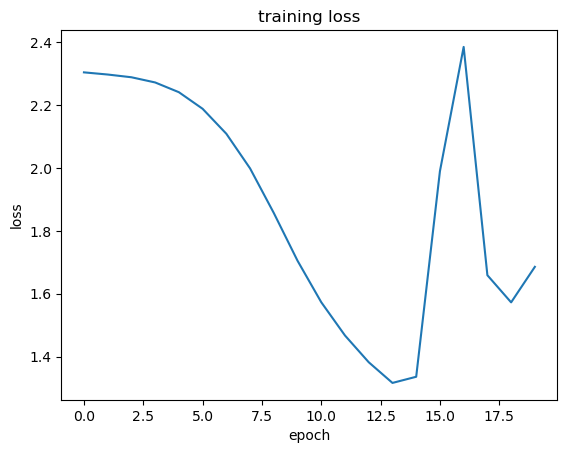

In [17]:
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training loss")
plt.show()

## verifying gradients using pytorch

In [43]:
import torch
import torch.nn as nn

# recomputing numpy gradients such that comparison happens for same timestamp calculations

hidden_input = X @ W1_start + b1_start
hidden_output = np.maximum(0, hidden_input) # ReLu

output_input = hidden_output @ W2_start + b2_start
output_input_shifted = output_input - np.max(output_input, axis=1, keepdims=True)
exp_values = np.exp(output_input_shifted)
predictions = exp_values / np.sum(exp_values, axis=1, keepdims=True)  # Soft max

# loss
output_error = (predictions - Y) / X.shape[0]
dW2_np = hidden_output.T @ output_error
db2_np = np.sum(output_error, axis=0)    

hidden_error = output_error @ W2_start.T
hidden_error = hidden_error * (hidden_input > 0)
dW1_np = X.T @ hidden_error
db1_np = np.sum(hidden_error, axis=0)



# same network in pytorch with the same starting weights
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_start.T, dtype=torch.float32))
    model[0].bias.copy_(torch.tensor(b1_start, dtype=torch.float32))
    model[2].weight.copy_(torch.tensor(W2_start.T, dtype=torch.float32))
    model[2].bias.copy_(torch.tensor(b2_start, dtype=torch.float32))

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y_labels, dtype=torch.long)

out = model(X_t)
loss_fn = nn.CrossEntropyLoss()
loss_t = loss_fn(out, y_t)
loss_t.backward()

dW1_torch = model[0].weight.grad.numpy().T
db1_torch = model[0].bias.grad.numpy()
dW2_torch = model[2].weight.grad.numpy().T
db2_torch = model[2].bias.grad.numpy()

print(np.max(np.abs(dW1_np - dW1_torch)))
print(np.max(np.abs(db1_np - db1_torch)))
print(np.max(np.abs(dW2_np - dW2_torch)))
print(np.max(np.abs(db2_np - db2_torch)))

3.651108202232245e-09
4.2081042816999314e-09
1.6158221066708833e-08
4.75215587020239e-09


### The biggest difference between my numpy gradients and PyTorche gradients was extremely small (10^-8 or -9 which is approx zero)
### This confirms that my manual forward pass, backward pass, and loss calculations are correct. As both gave almost same results.

# Part 2: Baseline Model and Activation Study

## environment setup

In [118]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)  # reproduceablity

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

## layering(at least two) and model (train one version each with sigmoid, tanh, ReLU and leaky ReLU)

In [119]:
import torch.nn as nn

def build_model(activation_fn):
    return nn.Sequential(
        # Hidden Layer 1 takes input_size=784, outputs 128
        nn.Linear(in_features=784, out_features=128),
        activation_fn,
        
        # Hidden Layer 2 takes 128, outputs 64
        nn.Linear(in_features=128, out_features=64),
        activation_fn,
        
        # Output Layer takes 64, outputs 10 (as we have 10 labels)
        nn.Linear(in_features=64, out_features=10)
    )

activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU(),
    "leaky_relu": nn.LeakyReLU(0.01)
}

## training all four

In [120]:
epochs = 20
learning_rate = 0.01

val_loss_history = {}
grad_records = {}   # store epoch 1 and final epoch mean 


for name, act in activations.items():
    torch.manual_seed(42)   # same starting weights for every model
    model = build_model(act)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()

    val_losses = []
    first_epoch_grad = None
    final_epoch_grad = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train_t)
        loss = loss_fn(out, y_train_t)
        loss.backward()

        mean_abs_grad = model[0].weight.grad.abs().mean().item()
        if epoch == 0:
            first_epoch_grad = mean_abs_grad
        if epoch == epochs - 1:
            final_epoch_grad = mean_abs_grad

        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = loss_fn(val_out, y_val_t).item()
        val_losses.append(val_loss)

    val_loss_history[name] = val_losses
    grad_records[name] = (first_epoch_grad, final_epoch_grad)

    # keeping the trained relu model
    if name == "relu":
        relu_model = model

## plotting loss curves

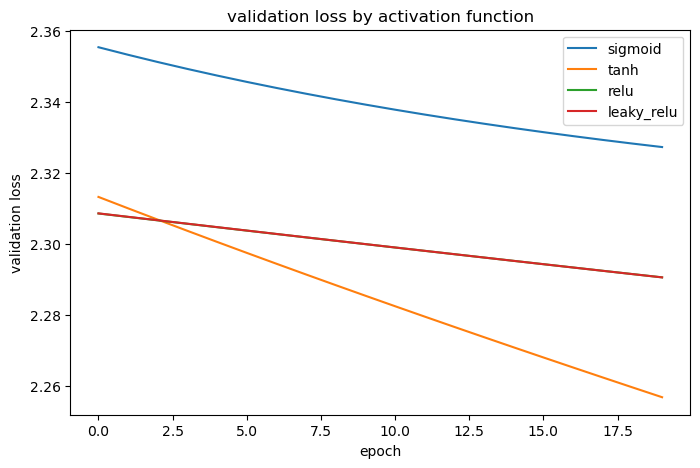

In [121]:
plt.figure(figsize=(8,5))
for name, losses in val_loss_history.items():
    plt.plot(losses, label=name)
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("validation loss by activation function")
plt.legend()
plt.show()

## reporting gradiants


In [122]:
print("sigmoid - epoch 1 grad:", grad_records["sigmoid"][0])
print("sigmoid - final epoch grad:", grad_records["sigmoid"][1])
print("relu - epoch 1 grad:", grad_records["relu"][0])
print("relu - final epoch grad:", grad_records["relu"][1])

sigmoid - epoch 1 grad: 9.163616050500423e-05
sigmoid - final epoch grad: 8.272795821540058e-05
relu - epoch 1 grad: 0.0005562691949307919
relu - final epoch grad: 0.0005437485524453223


## dead ReLu

In [123]:
relu_model.eval()
with torch.no_grad():
    h1 = relu_model[0](X_val_t)
    h1 = relu_model[1](h1)   # after first ReLU

# "dead" if it outputs 0 for every sample in the batch
dead_units = (h1 == 0).all(dim=0)
percent_dead = dead_units.float().mean().item() * 100

print(f"{percent_dead:}% of first-layer units are dead")

0.0% of first-layer units are dead


In [125]:
torch.manual_seed(42)
relu_model = build_model(nn.ReLU())
optimizer = torch.optim.Adam(relu_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

epochs = 30
relu_val_losses = []

for epoch in range(epochs):
    relu_model.train()
    optimizer.zero_grad()
    out = relu_model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

    relu_model.eval()
    with torch.no_grad():
        val_out = relu_model(X_val_t)
        val_loss = loss_fn(val_out, y_val_t)
    relu_val_losses.append(val_loss.item())

print("Retraining complete.")

Retraining complete.


In [126]:
relu_model.eval()
with torch.no_grad():
    val_preds = relu_model(X_val_t).argmax(dim=1)
    relu_val_acc = (val_preds == y_val_t).float().mean().item()

print(f"Part 2 ReLU baseline accuracy: {relu_val_acc*100:.2f}%")

Part 2 ReLU baseline accuracy: 71.75%


## Conculsion:

#### Vanishing Gradients: Sigmoid's gradient magnitude (9.16×10^-5) is about 6 times smaller than ReLU's (5.56×10^-4), because Sigmoid's shrinking function has a very small derivativeeverytime, causing the gradient to shrink drastically. ReLU avoids this since its derivative is a constant 1 for all positive inputs. ReLu doesn't shrink the gradiants that's why its value is 6 times larger.


#### Dead-Unit Percentage: The first layer shows 0.0% dead units, meaning every neuron produced a positive output. none of them were permanently stuck outputting zero. This indicates the learning rate and weight initialization were well-tuned.



# Part 3: Loss Functions

## one-hot targets for MSE + accuracy func

In [25]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# one-hot encode targets for the MSE 

y_train_onehot = torch.nn.functional.one_hot(y_train_t, num_classes=10).float()
y_val_onehot   = torch.nn.functional.one_hot(y_val_t, num_classes=10).float()


def accuracy(model, X, y_true_labels):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        acc = (preds == y_true_labels).float().mean().item()
    return acc

## training with cross-entropy:


In [26]:
torch.manual_seed(42)
model_ce = build_model(nn.ReLU())
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=0.001)
loss_fn_ce = nn.CrossEntropyLoss()

epochs = 50
ce_losses = []

for epoch in range(epochs):
    model_ce.train()
    optimizer_ce.zero_grad()
    out = model_ce(X_train_t)
    loss = loss_fn_ce(out, y_train_t)
    loss.backward()
    optimizer_ce.step()
    ce_losses.append(loss.item())

ce_test_acc = accuracy(model_ce, X_val_t, y_val_t)
print(f"Cross-Entropy test accuracy: {ce_test_acc*100}%")

Cross-Entropy test accuracy: 78.66666913032532%


## training identical network using MSE on one-hot targets

In [27]:
torch.manual_seed(42)
model_mse = build_model(nn.ReLU())
optimizer_mse = torch.optim.Adam(model_mse.parameters(), lr=0.001)
loss_fn_mse = nn.MSELoss()
softmax = nn.Softmax(dim=1)

mse_losses = []

for epoch in range(epochs):
    model_mse.train()
    optimizer_mse.zero_grad()
    out = model_mse(X_train_t)
    probs = softmax(out)
    loss = loss_fn_mse(probs, y_train_onehot)
    loss.backward()
    optimizer_mse.step()
    mse_losses.append(loss.item())

mse_test_acc = accuracy(model_mse, X_val_t, y_val_t)
print(f"MSE test accuracy: {mse_test_acc*100}%")

MSE test accuracy: 79.3916642665863%


## ploting both training curves

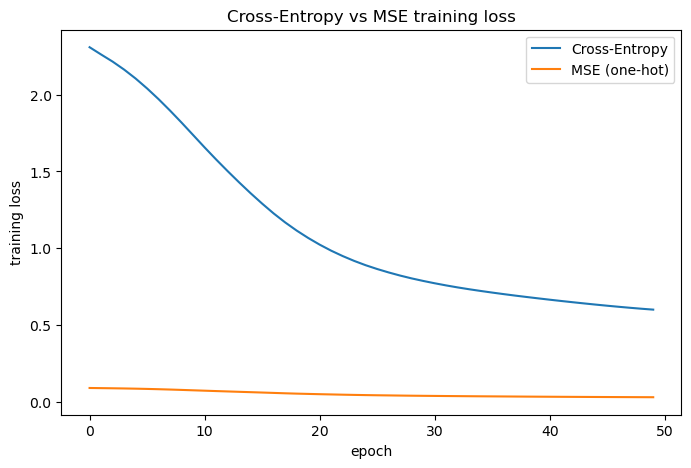

In [28]:
plt.figure(figsize=(8,5))
plt.plot(ce_losses, label="Cross-Entropy")
plt.plot(mse_losses, label="MSE (one-hot)")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Cross-Entropy vs MSE training loss")
plt.legend()
plt.show()

## Conclusion:
The MSE curve looks flatter than the Cross-Entropy curve, but that's because the two
losses start at very different scales (CE starts around 2.3, MSE starts around 0.1), so
their slopes can't be compared directly on the same plot. In theory, Cross-Entropy should
still learn faster than MSE, because MSE's gradient can shrink and slow down when the
model is confidently wrong. In this run, both models ended with similar test accuracy
(CE: 78.67%, MSE: 79.39%), likely because Adam adjusts the learning rate automatically and
reduces this difference. With a simpler optimizer like plain SGD, Cross-Entropy would
likely show a clearer speed advantage.

## Showing with SGD to show the difference between MSE and CE

### cross entropy with sgd

In [29]:
torch.manual_seed(42)
model_ce = build_model(nn.ReLU())
optimizer_ce = torch.optim.SGD(model_ce.parameters(), lr=0.3)
loss_fn_ce = nn.CrossEntropyLoss()

epochs = 100
ce_losses = []

for epoch in range(epochs):
    model_ce.train()
    optimizer_ce.zero_grad()
    out = model_ce(X_train_t)
    loss = loss_fn_ce(out, y_train_t)
    loss.backward()
    optimizer_ce.step()
    ce_losses.append(loss.item())

ce_test_acc = accuracy(model_ce, X_val_t, y_val_t)
print(f"Cross-Entropy test accuracy: {ce_test_acc*100}%")

Cross-Entropy test accuracy: 72.85000085830688%


## MSE with sgd

In [30]:
torch.manual_seed(42)
model_mse = build_model(nn.ReLU())
optimizer_mse = torch.optim.SGD(model_mse.parameters(), lr=0.3)
loss_fn_mse = nn.MSELoss()
softmax = nn.Softmax(dim=1)

mse_losses = []

for epoch in range(epochs):
    model_mse.train()
    optimizer_mse.zero_grad()
    out = model_mse(X_train_t)
    probs = softmax(out)
    loss = loss_fn_mse(probs, y_train_onehot)
    loss.backward()
    optimizer_mse.step()
    mse_losses.append(loss.item())

mse_test_acc = accuracy(model_mse, X_val_t, y_val_t)
print(f"MSE test accuracy: {mse_test_acc*100}%")

MSE test accuracy: 19.741666316986084%


## plotting the curve again

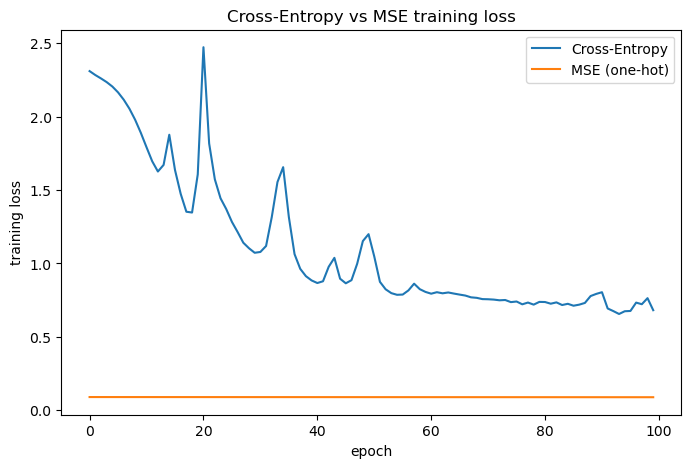

In [31]:
plt.figure(figsize=(8,5))
plt.plot(ce_losses, label="Cross-Entropy")
plt.plot(mse_losses, label="MSE (one-hot)")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Cross-Entropy vs MSE training loss")
plt.legend()
plt.show()

## conclusion:
for the same number of epochs(100) we can see that CE converged to 72.5% accuracy but MSE is still at 19.7% this shows that CE converges faster and this can be seen when using simpler optimizer like SGD

## Final comparison:

Cross-Entropy learns faster than MSE because of how the error signal is calculated.

With Cross-Entropy, the gradient is just "prediction minus target." 
So if the model is very wrong, it gets a big, strong push
to correct itself.

With MSE, the gradient is smaller when the model's prediction is close to 0 or 1, even if
that prediction is wrong. So the model gets a weak push instead of a strong one, and it
learns more slowly.

That's why Cross-Entropy usually trains faster for classification.


## tabular regression: small MLP on the diabetes dataset

In [32]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# load a small built-in tabular regression dataset
data = load_diabetes()
X_reg, y_reg = data.data, data.target

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_X = StandardScaler().fit(X_tr)
X_tr = scaler_X.transform(X_tr)
X_te = scaler_X.transform(X_te)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.float32).view(-1, 1)

reg_model = nn.Sequential(
    nn.Linear(X_tr.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer_reg = torch.optim.Adam(reg_model.parameters(), lr=0.01)
loss_fn_reg = nn.MSELoss()

for epoch in range(200):
    reg_model.train()
    optimizer_reg.zero_grad()
    pred = reg_model(X_tr_t)
    loss = loss_fn_reg(pred, y_tr_t)
    loss.backward()
    optimizer_reg.step()

reg_model.eval()
with torch.no_grad():
    y_pred = reg_model(X_te_t).numpy().flatten()

mse = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te, y_pred)

print(f"Test MSE:  {mse}")
print(f"Test RMSE: {rmse}")
print(f"Test MAE:  {mae}")

Test MSE:  2788.8188580606443
Test RMSE: 52.80926867568461
Test MAE:  42.42278195499034


## Conclusion:
MSE, RMSE, and MAE all measure how wrong the model's predictions were, but in different
ways. MSE squares the errors before averaging, so it punishes big mistakes more than small
ones. RMSE is just the square root of MSE, so it brings the error back to the original
scale of the target, making it easier to understand. MAE simply averages the errors
without squaring them, so it treats every mistake equally, big or small.

In this case, RMSE (52.8) is higher than MAE (42.4). This difference shows that some
predictions had larger errors than others, since RMSE reacts more strongly to big mistakes
than MAE does.

# Part 4: Optimiser Comparison
same architecture with SGD, SGD+momentum, RMSProp, and Adam

## shared parameters

In [33]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

epochs = 100
same_lr = 0.01   # same learning rate used for all four optimisers

# to store results from each optimiser
all_results = []

## training with SGD

In [35]:
torch.manual_seed(42)
model = build_model(nn.ReLU())
optimizer = torch.optim.SGD(model.parameters(), lr=same_lr)
loss_fn = nn.CrossEntropyLoss()

losses = []
epoch_reached_85 = None

start_time = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    # checking validation accuracy 
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    if epoch_reached_85 is None and val_acc >= 0.85:
        epoch_reached_85 = epoch + 1

time_taken = time.time() - start_time
final_acc = val_acc

print(f"SGD epochs to reach 85%: {epoch_reached_85}, final val acc: {final_acc*100}%, time: {time_taken}s")

# saving this optimiser results in the previously initialized array
all_results.append({"name": "SGD", "lr": same_lr, "losses": losses,
                    "epochs_to_85": epoch_reached_85, "final_acc": final_acc, "time": time_taken})

SGD epochs to reach 85%: None, final val acc: 20.04166692495346%, time: 36.96182131767273s


## training with SGD + momentum

In [36]:
torch.manual_seed(42)
model = build_model(nn.ReLU())
optimizer = torch.optim.SGD(model.parameters(), lr=same_lr, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

losses = []
epoch_reached_85 = None

start_time = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    if epoch_reached_85 is None and val_acc >= 0.85:
        epoch_reached_85 = epoch + 1

time_taken = time.time() - start_time
final_acc = val_acc

print(f"SGD+momentum:  epochs to reach 85%: {epoch_reached_85}, final val acc: {final_acc*100}%, time: {time_taken}s")

all_results.append({"name": "SGD+momentum", "lr": same_lr, "losses": losses,
                     "epochs_to_85": epoch_reached_85, "final_acc": final_acc, "time": time_taken})

SGD+momentum:  epochs to reach 85%: None, final val acc: 68.7166690826416%, time: 37.61346507072449s


## training with RMSprop

In [37]:
torch.manual_seed(42)
model = build_model(nn.ReLU())
optimizer = torch.optim.RMSprop(model.parameters(), lr=same_lr)
loss_fn = nn.CrossEntropyLoss()

losses = []
epoch_reached_85 = None

start_time = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    if epoch_reached_85 is None and val_acc >= 0.85:
        epoch_reached_85 = epoch + 1

time_taken = time.time() - start_time
final_acc = val_acc

print(f"RMSProp:  epochs to reach 85%: {epoch_reached_85}, final val acc: {final_acc*100}%, time: {time_taken}s")

all_results.append({"name": "RMSProp", "lr": same_lr, "losses": losses,
                     "epochs_to_85": epoch_reached_85, "final_acc": final_acc, "time": time_taken})

RMSProp:  epochs to reach 85%: None, final val acc: 79.6916663646698%, time: 10.002154111862183s


## training with adam

In [38]:
torch.manual_seed(42)
model = build_model(nn.ReLU())
optimizer = torch.optim.Adam(model.parameters(), lr=same_lr)
loss_fn = nn.CrossEntropyLoss()

losses = []
epoch_reached_85 = None

start_time = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    if epoch_reached_85 is None and val_acc >= 0.85:
        epoch_reached_85 = epoch + 1

time_taken = time.time() - start_time
final_acc = val_acc

print(f"Adam:  epochs to reach 85%: {epoch_reached_85}, final val acc: {final_acc*100:.2f}%, time: {time_taken:.2f}s")

all_results.append({"name": "Adam", "lr": same_lr, "losses": losses,
                     "epochs_to_85": epoch_reached_85, "final_acc": final_acc, "time": time_taken})

Adam:  epochs to reach 85%: 67, final val acc: 87.02%, time: 13.35s


## building the results table

In [89]:
import pandas as pd

table_same_lr = pd.DataFrame([{
    "Optimiser": r["name"],
    "Learning rate": r["lr"],
    "Epochs to reach 85% val accuracy": r["epochs_to_85"] if r["epochs_to_85"] is not None else "not reached",
    "Final validation accuracy": f"{r['final_acc']*100:.2f}%",
    "Wall-clock time (s)": f"{r['time']:.2f}"
} for r in all_results])

table_same_lr

,Optimiser,Learning rate,Epochs to reach 85% val accuracy,Final validation accuracy,Wall-clock time (s)
0,SGD,0.01,not reached,20.04%,37.01
1,SGD,0.01,not reached,20.04%,36.96
2,SGD+momentum,0.01,not reached,68.72%,37.61
3,RMSProp,0.01,not reached,79.69%,10.00
4,Adam,0.01,67,87.02%,13.35


## ploting all four curves

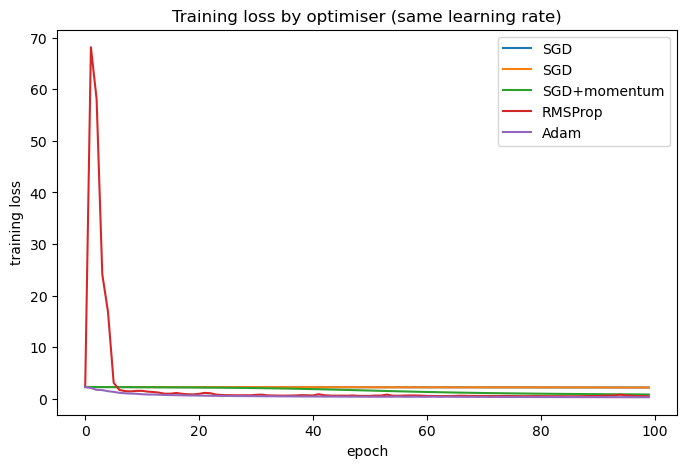

In [41]:
plt.figure(figsize=(8,5))
for r in all_results:
    plt.plot(r["losses"], label=r["name"])
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss by optimiser (same learning rate)")
plt.legend()
plt.show()

## Conclusion (same learning rate, lr = 0.01):
At the same learning rate, the four optimisers performed very differently. 
### Plain SGD
struggled the most, reaching only 20.04% final accuracy and its learning rate was too small
for it to make real progress. 
### SGD with momentum 
did better (68.72%), since momentum helps push through slow, flat regions of the loss. 
### RMSProp 
reached 79.69%, but its loss curve shows a large spike early in training before settling down, 
meaning it was unstable at first before recovering. 
### Adam 
performed best overall, reaching 87.02% accuracy and hitting
the 85% target by epoch 67, showing it adapted well even without a learning rate tuned
specifically for it.

Overall, this shows that using the same learning rate for every optimiser is not a fair
comparison:
some optimisers (like Adam) can handle a wide range of learning rates well,
while others (like plain SGD) need a much more tuned learning rate to perform properly. 

# Part 5: Forcing Overfitting

## Setup (for overfitting: small training set, big network)

In [53]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# reduce training set to 2000 samples
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

X_train_t = torch.tensor(X_train_small, dtype=torch.float32)
y_train_t = torch.tensor(y_train_small, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# big network: 4 hidden layers of 512 units each
model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

## training long enough 
that model starts memorizing instead of learning and keeping a check through accuracy and loss

In [54]:
epochs = 200 ## the more the epochs the more the overfitting

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_acc = (out.argmax(dim=1) == y_train_t).float().mean().item()
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t)
        val_loss = loss_fn(val_out, y_val_t).item()
        val_acc = (val_out.argmax(dim=1) == y_val_t).float().mean().item()

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}, train_acc {train_acc}, val_acc {val_acc}")

print(f"\nfinal train accuracy: {train_accuracies[-1]}")
print(f"final val accuracy: {val_accuracies[-1]}")

epoch 10, train_acc 0.5, val_acc 0.48341667652130127
epoch 20, train_acc 0.6514999866485596, val_acc 0.6510000228881836
epoch 30, train_acc 0.7400000095367432, val_acc 0.7249166369438171
epoch 40, train_acc 0.7714999914169312, val_acc 0.7662500143051147
epoch 50, train_acc 0.8270000219345093, val_acc 0.7875833511352539
epoch 60, train_acc 0.8410000205039978, val_acc 0.7926666736602783
epoch 70, train_acc 0.8669999837875366, val_acc 0.796500027179718
epoch 80, train_acc 0.8870000243186951, val_acc 0.8069166541099548
epoch 90, train_acc 0.906499981880188, val_acc 0.812583327293396
epoch 100, train_acc 0.9135000109672546, val_acc 0.7911666631698608
epoch 110, train_acc 0.9154999852180481, val_acc 0.8148333430290222
epoch 120, train_acc 0.934499979019165, val_acc 0.8209166526794434
epoch 130, train_acc 0.9484999775886536, val_acc 0.8227499723434448
epoch 140, train_acc 0.8855000138282776, val_acc 0.7829166650772095
epoch 150, train_acc 0.9495000243186951, val_acc 0.8159999847412109
epoch 1

# finding where the curves separate

In [68]:
# finding the epoch point where the gap between train and val loss occurs

gap_threshold = 0.06
separation_epoch = None

for i in range(len(train_losses)):
    gap = val_losses[i] - train_losses[i]
    if gap > gap_threshold:
        separation_epoch = i
        break

print(f"curves separate around epoch {separation_epoch}")

curves separate around epoch 29


## ploting training vs validation loss
marking the separation point

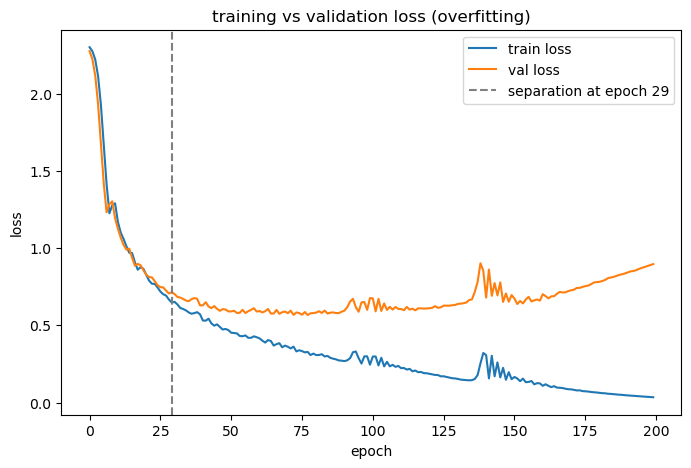

In [69]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

if separation_epoch is not None:
    plt.axvline(x=separation_epoch, color="gray", linestyle="--",
                label=f"separation at epoch {separation_epoch}")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training vs validation loss (overfitting)")
plt.legend()
plt.show()

### the generalization gap

In [70]:
gen_gap = train_accuracies[-1] - val_accuracies[-1]
print(f"final train accuracy: {train_accuracies[-1]}")
print(f"final val accuracy: {val_accuracies[-1]}")
print(f"generalisation gap: {gen_gap}")

final train accuracy: 0.9955000281333923
final val accuracy: 0.8227499723434448
generalisation gap: 0.1727500557899475


## Conclusion:
The final training accuracy was 99.55% while validation accuracy was 82.27%, giving a generalisation gap of 17.28 percentage points. 
training accuracy is above 99%, the model fits the training data almost perfectly that means 
### it is not high bias (because in high bias model is to simple to even fit the data). 
The large gap between training and validation accuracy shows the model has memorized the small 2000-sample training set rather than learning generalizable patterns
### that means this is high variance (because it has memorized the training set)
and this is because the network's size is HUGE relative to the tiny training set.

# Part 6: Regularisation Study

## set up

In [71]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

X_train_t = torch.tensor(X_train_small, dtype=torch.float32)
y_train_t = torch.tensor(y_train_small, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

loss_fn = nn.CrossEntropyLoss()
epochs = 100

## no regularization

In [72]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    train_acc_baseline = (model(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_baseline = (model(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_baseline = train_acc_baseline - val_acc_baseline

print("train acc:", train_acc_baseline)
print("val acc:", val_acc_baseline)
print("gap:", gap_baseline)

train acc: 0.887499988079071
val acc: 0.7911666631698608
gap: 0.0963333249092102


# L2 tested at a minimum of three values of lambda

## lamda 1 = 0.0001

In [73]:
torch.manual_seed(42)

model_l2a = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_l2a.parameters(), lr=0.001, weight_decay=0.0001)

for epoch in range(epochs):
    model_l2a.train()
    optimizer.zero_grad()
    out = model_l2a(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_l2a.eval()
with torch.no_grad():
    train_acc_l2a = (model_l2a(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_l2a = (model_l2a(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_l2a = train_acc_l2a - val_acc_l2a

print("train acc:", train_acc_l2a)
print("val acc:", val_acc_l2a)
print("gap:", gap_l2a)

train acc: 0.9020000100135803
val acc: 0.8069166541099548
gap: 0.09508335590362549


## lamda 2 = 0.001

In [75]:
torch.manual_seed(42)

model_l2b = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_l2b.parameters(), lr=0.001, weight_decay=0.001)

for epoch in range(epochs):
    model_l2b.train()
    optimizer.zero_grad()
    out = model_l2b(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_l2b.eval()
with torch.no_grad():
    train_acc_l2b = (model_l2b(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_l2b = (model_l2b(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_l2b = train_acc_l2b - val_acc_l2b

print("train acc:", train_acc_l2b)
print("val acc:", val_acc_l2b)
print("gap:", gap_l2b)

train acc: 0.8899999856948853
val acc: 0.8043333292007446
gap: 0.08566665649414062


## lamda 3 = 0.01

In [76]:
torch.manual_seed(42)

model_l2c = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_l2c.parameters(), lr=0.001, weight_decay=0.01)

for epoch in range(epochs):
    model_l2c.train()
    optimizer.zero_grad()
    out = model_l2c(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_l2c.eval()
with torch.no_grad():
    train_acc_l2c = (model_l2c(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_l2c = (model_l2c(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_l2c = train_acc_l2c - val_acc_l2c

print("train acc:", train_acc_l2c)
print("val acc:", val_acc_l2c)
print("gap:", gap_l2c)

train acc: 0.7825000286102295
val acc: 0.7394166588783264
gap: 0.043083369731903076


# L1 penalty

In [77]:
torch.manual_seed(42)

model_l1 = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_l1.parameters(), lr=0.001)
l1_lambda = 0.0001

for epoch in range(epochs):
    model_l1.train()
    optimizer.zero_grad()
    out = model_l1(X_train_t)
    loss = loss_fn(out, y_train_t)

    # add L1 penalty: sum of absolute value of all weights
    l1_penalty = 0
    for param in model_l1.parameters():
        l1_penalty = l1_penalty + param.abs().sum()
    loss = loss + l1_lambda * l1_penalty

    loss.backward()
    optimizer.step()

model_l1.eval()
with torch.no_grad():
    train_acc_l1 = (model_l1(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_l1 = (model_l1(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_l1 = train_acc_l1 - val_acc_l1

print("train acc:", train_acc_l1)
print("val acc:", val_acc_l1)
print("gap:", gap_l1)

train acc: 0.8004999756813049
val acc: 0.7505000233650208
gap: 0.04999995231628418


## Reporting the percentage of weights below 1e-3 after training.

In [78]:
# collect all weight values into one list
all_weights = []
for param in model_l1.parameters():
    if param.dim() > 1:   # only weight matrices, not biases
        all_weights.append(param.flatten())

all_weights = torch.cat(all_weights)
near_zero_count = (all_weights.abs() < 1e-3).sum().item()
total_count = all_weights.numel()

percent_near_zero = 100 * near_zero_count / total_count
print("percent of weights below 1e-3:", percent_near_zero)

percent of weights below 1e-3: 64.93847237124463


# Drop out tested for minimum 3 rates

## rate 1 = 0.2

In [79]:
torch.manual_seed(42)

model_drop_a = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_drop_a.parameters(), lr=0.001)

for epoch in range(epochs):
    model_drop_a.train()
    optimizer.zero_grad()
    out = model_drop_a(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_drop_a.eval()
with torch.no_grad():
    train_acc_drop_a = (model_drop_a(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_drop_a = (model_drop_a(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_drop_a = train_acc_drop_a - val_acc_drop_a

print("train acc:", train_acc_drop_a)
print("val acc:", val_acc_drop_a)
print("gap:", gap_drop_a)

train acc: 0.9445000290870667
val acc: 0.8257499933242798
gap: 0.11875003576278687


## rate 2 = 0.5

In [80]:
torch.manual_seed(42)

model_drop_b = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_drop_b.parameters(), lr=0.001)

for epoch in range(epochs):
    model_drop_b.train()
    optimizer.zero_grad()
    out = model_drop_b(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_drop_b.eval()
with torch.no_grad():
    train_acc_drop_b = (model_drop_b(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_drop_b = (model_drop_b(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_drop_b = train_acc_drop_b - val_acc_drop_b

print("train acc:", train_acc_drop_b)
print("val acc:", val_acc_drop_b)
print("gap:", gap_drop_b)

train acc: 0.9474999904632568
val acc: 0.828249990940094
gap: 0.11924999952316284


## rate 3= 0.75

In [81]:
torch.manual_seed(42)

model_drop_c = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.75),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.75),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.75),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.75),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_drop_c.parameters(), lr=0.001)

for epoch in range(epochs):
    model_drop_c.train()
    optimizer.zero_grad()
    out = model_drop_c(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_drop_c.eval()
with torch.no_grad():
    train_acc_drop_c = (model_drop_c(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_drop_c = (model_drop_c(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_drop_c = train_acc_drop_c - val_acc_drop_c

print("train acc:", train_acc_drop_c)
print("val acc:", val_acc_drop_c)
print("gap:", gap_drop_c)

train acc: 0.7724999785423279
val acc: 0.734083354473114
gap: 0.03841662406921387


# Batch normalization

In [82]:
torch.manual_seed(42)

model_bn = nn.Sequential(
    nn.Linear(784, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_bn.parameters(), lr=0.001)

for epoch in range(epochs):
    model_bn.train()
    optimizer.zero_grad()
    out = model_bn(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_bn.eval()
with torch.no_grad():
    train_acc_bn = (model_bn(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_bn = (model_bn(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_bn = train_acc_bn - val_acc_bn

print("train acc:", train_acc_bn)
print("val acc:", val_acc_bn)
print("gap:", gap_bn)

train acc: 1.0
val acc: 0.825083315372467
gap: 0.17491668462753296


# Early stopping

In [83]:
torch.manual_seed(42)

model_early = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_early.parameters(), lr=0.001)

patience = 10
best_val_loss = float("inf")
wait_count = 0
stopped_epoch = None

for epoch in range(200):
    model_early.train()
    optimizer.zero_grad()
    out = model_early(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

    model_early.eval()
    with torch.no_grad():
        val_loss = loss_fn(model_early(X_val_t), y_val_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait_count = 0
    else:
        wait_count = wait_count + 1

    if wait_count >= patience:
        stopped_epoch = epoch + 1
        print("stopped early at epoch", stopped_epoch)
        break

model_early.eval()
with torch.no_grad():
    train_acc_early = (model_early(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_early = (model_early(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_early = train_acc_early - val_acc_early

print("train acc:", train_acc_early)
print("val acc:", val_acc_early)
print("gap:", gap_early)

stopped early at epoch 88
train acc: 0.9039999842643738
val acc: 0.8147500157356262
gap: 0.08924996852874756


## Data augmentation flip + rotation

In [85]:
from scipy.ndimage import rotate
import random

torch.manual_seed(42)

model_aug = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_aug.parameters(), lr=0.001)

# reshape training images to 28x28 once, so we can flip/rotate them
images_2d = X_train_t.view(-1, 28, 28).numpy()

for epoch in range(epochs):
    augmented_images = []

    for img in images_2d:
        if random.random() < 0.5:
            img = np.flip(img, axis=1)   # horizontal flip
        angle = random.uniform(-10, 10)
        img = rotate(img, angle, reshape=False, mode="nearest")
        augmented_images.append(img)

    augmented_images = np.array(augmented_images)
    X_aug = torch.tensor(augmented_images, dtype=torch.float32).view(-1, 784)

    model_aug.train()
    optimizer.zero_grad()
    out = model_aug(X_aug)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()

model_aug.eval()
with torch.no_grad():
    train_acc_aug = (model_aug(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
    val_acc_aug = (model_aug(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_aug = train_acc_aug - val_acc_aug

print("train acc:", train_acc_aug)
print("val acc:", val_acc_aug)
print("gap:", gap_aug)

train acc: 0.8604999780654907
val acc: 0.8054166436195374
gap: 0.05508333444595337


## More training data 10,000

In [86]:
torch.manual_seed(42)

X_train_10k = torch.tensor(X_train[:10000], dtype=torch.float32)
y_train_10k = torch.tensor(y_train[:10000], dtype=torch.long)

model_10k = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_10k.parameters(), lr=0.001)

for epoch in range(epochs):
    model_10k.train()
    optimizer.zero_grad()
    out = model_10k(X_train_10k)
    loss = loss_fn(out, y_train_10k)
    loss.backward()
    optimizer.step()

model_10k.eval()
with torch.no_grad():
    train_acc_10k = (model_10k(X_train_10k).argmax(dim=1) == y_train_10k).float().mean().item()
    val_acc_10k = (model_10k(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_10k = train_acc_10k - val_acc_10k

print("train acc:", train_acc_10k)
print("val acc:", val_acc_10k)
print("gap:", gap_10k)

train acc: 0.8756999969482422
val acc: 0.8478333353996277
gap: 0.027866661548614502


## More training data 20,000

In [87]:
torch.manual_seed(42)

X_train_20k = torch.tensor(X_train[:20000], dtype=torch.float32)
y_train_20k = torch.tensor(y_train[:20000], dtype=torch.long)

model_20k = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10)
)

optimizer = torch.optim.Adam(model_20k.parameters(), lr=0.001)

for epoch in range(epochs):
    model_20k.train()
    optimizer.zero_grad()
    out = model_20k(X_train_20k)
    loss = loss_fn(out, y_train_20k)
    loss.backward()
    optimizer.step()

model_20k.eval()
with torch.no_grad():
    train_acc_20k = (model_20k(X_train_20k).argmax(dim=1) == y_train_20k).float().mean().item()
    val_acc_20k = (model_20k(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

gap_20k = train_acc_20k - val_acc_20k

print("train acc:", train_acc_20k)
print("val acc:", val_acc_20k)
print("gap:", gap_20k)

train acc: 0.8647000193595886
val acc: 0.8512499928474426
gap: 0.013450026512145996


In [91]:
import pandas as pd

all_results = [
    {"method": "Baseline", "setting": "-", "train_acc": train_acc_baseline, "val_acc": val_acc_baseline, "gap": gap_baseline},
    {"method": "L2 weight decay", "setting": "lambda=0.0001", "train_acc": train_acc_l2a, "val_acc": val_acc_l2a, "gap": gap_l2a},
    {"method": "L2 weight decay", "setting": "lambda=0.001", "train_acc": train_acc_l2b, "val_acc": val_acc_l2b, "gap": gap_l2b},
    {"method": "L2 weight decay", "setting": "lambda=0.01", "train_acc": train_acc_l2c, "val_acc": val_acc_l2c, "gap": gap_l2c},
    {"method": "L1 penalty", "setting": "lambda=0.0001", "train_acc": train_acc_l1, "val_acc": val_acc_l1, "gap": gap_l1},
    {"method": "Dropout", "setting": "p=0.2", "train_acc": train_acc_drop_a, "val_acc": val_acc_drop_a, "gap": gap_drop_a},
    {"method": "Dropout", "setting": "p=0.5", "train_acc": train_acc_drop_b, "val_acc": val_acc_drop_b, "gap": gap_drop_b},
    {"method": "Dropout", "setting": "p=0.75", "train_acc": train_acc_drop_c, "val_acc": val_acc_drop_c, "gap": gap_drop_c},
    {"method": "Batch normalisation", "setting": "-", "train_acc": train_acc_bn, "val_acc": val_acc_bn, "gap": gap_bn},
    {"method": "Early stopping", "setting": f"patience={patience}, stopped at {stopped_epoch}", "train_acc": train_acc_early, "val_acc": val_acc_early, "gap": gap_early},
    {"method": "Data augmentation", "setting": "flip + rotation", "train_acc": train_acc_aug, "val_acc": val_acc_aug, "gap": gap_aug},
    {"method": "More training data", "setting": "n=10000", "train_acc": train_acc_10k, "val_acc": val_acc_10k, "gap": gap_10k},
    {"method": "More training data", "setting": "n=20000", "train_acc": train_acc_20k, "val_acc": val_acc_20k, "gap": gap_20k},
]

results_table = pd.DataFrame([{
    "Method": r["method"],
    "Setting": r["setting"],
    "Train accuracy": f"{r['train_acc']*100:.2f}%",
    "Validation accuracy": f"{r['val_acc']*100:.2f}%",
    "Gap": f"{r['gap']*100:.2f}%"
} for r in all_results])

results_table

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline,-,88.75%,79.12%,9.63%
1,L2 weight decay,lambda=0.0001,90.20%,80.69%,9.51%
2,L2 weight decay,lambda=0.001,89.00%,80.43%,8.57%
3,L2 weight decay,lambda=0.01,78.25%,73.94%,4.31%
4,L1 penalty,lambda=0.0001,80.05%,75.05%,5.00%
5,Dropout,p=0.2,94.45%,82.57%,11.88%
6,Dropout,p=0.5,94.75%,82.82%,11.92%
7,Dropout,p=0.75,77.25%,73.41%,3.84%
8,Batch normalisation,-,100.00%,82.51%,17.49%
9,Early stopping,"patience=10, stopped at 88",90.40%,81.48%,8.92%


## Ploting gap vs strength for L2 and dropout

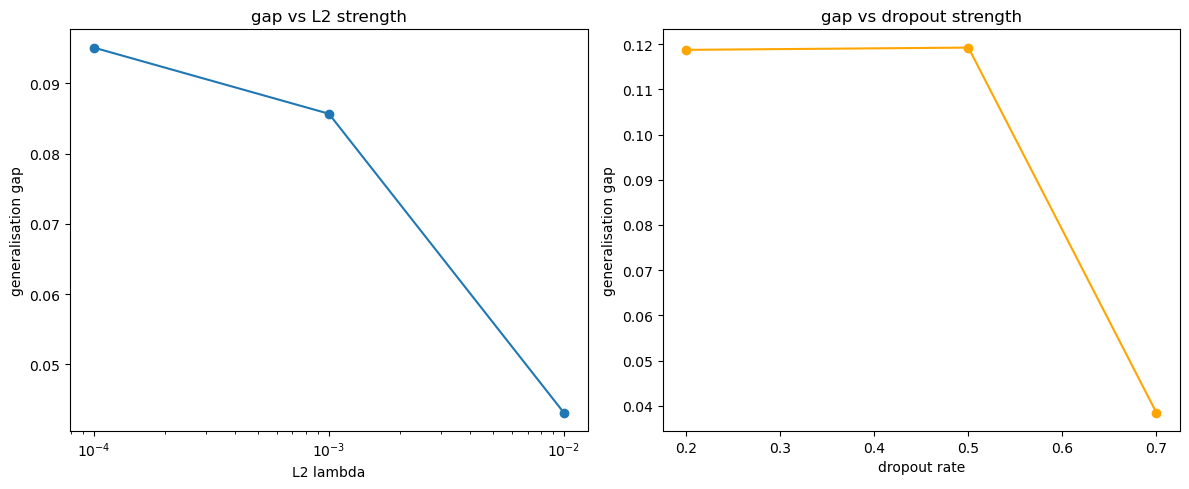

In [92]:
l2_values = [0.0001, 0.001, 0.01]
l2_gaps = [gap_l2a, gap_l2b, gap_l2c]

dropout_values = [0.2, 0.5, 0.7]
dropout_gaps = [gap_drop_a, gap_drop_b, gap_drop_c]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(l2_values, l2_gaps, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 lambda")
axes[0].set_ylabel("generalisation gap")
axes[0].set_title("gap vs L2 strength")

axes[1].plot(dropout_values, dropout_gaps, marker="o", color="orange")
axes[1].set_xlabel("dropout rate")
axes[1].set_ylabel("generalisation gap")
axes[1].set_title("gap vs dropout strength")

plt.tight_layout()
plt.show()

# Conclusion:

More training data gave the biggest gap reduction for the smallest cost in training accuracy. 
Using 20,000 samples dropped the gap from 9.63% (baseline) to just 1.35%, while training accuracy only fell slightly, from 88.75% to 86.47%.
Using 10,000 samples was almost as good, reducing the gap to 2.79% with a smaller drop in training accuracy (87.57%).

In comparison, strong L2 (lambda=0.01) and high dropout (p=0.75) also reduced the gap a lot (4.31% and 3.84%),
but at a much bigger cost training accuracy dropped to around 77-78%, showing the model was regularised too hard and couldn't even fit the training data well anymore.

### hence more data was the most efficient fix: it reduced overfitting without forcing the model to underperform on training data.

*************************

# PART 7: Hyperparameter Tuning with k-Fold Cross-Validation

************************************************************

## set up

In [95]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd
import time

np.random.seed(42)
torch.manual_seed(42)

## reusing the 20,000 samples from part 6

In [96]:
# converting to numpy for KFold splitting
X_20k = X_train_20k.numpy()
y_20k = y_train_20k.numpy()

print("Subset shape:", X_20k.shape, y_20k.shape)

Subset shape: (20000, 784) (20000,)


## model builder

In [97]:
def build_tunable_model(hidden_width, dropout_rate):
    return nn.Sequential(
        nn.Linear(784, hidden_width),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(hidden_width, hidden_width // 2),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(hidden_width // 2, 10)
    )

## function to train + evaluate one fold

In [98]:
def train_one_fold(X_tr, y_tr, X_val, y_val, lr, hidden_width, dropout_rate, batch_size, epochs=15):
    model = build_tunable_model(hidden_width, dropout_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # wraping training data in a DataLoader so batch_size can be used
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                              torch.tensor(y_tr, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=int(batch_size), shuffle=True)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()

    # evaluate once on this folds validation split
    model.eval()
    with torch.no_grad():
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        val_preds = model(X_val_t).argmax(dim=1).numpy()
    val_acc = accuracy_score(y_val, val_preds)
    return val_acc

## function to run 5-fold CV for one hyperparameter config

In [99]:
def cross_validate_config(config, X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        acc = train_one_fold(
            X_tr, y_tr, X_val, y_val,
            lr=config["lr"],
            hidden_width=config["hidden_width"],
            dropout_rate=config["dropout"],
            batch_size=config["batch_size"]
        )
        fold_accuracies.append(acc)

    return np.mean(fold_accuracies), np.std(fold_accuracies)

## Random search, sample configs and score each

In [101]:
n_configs = 12   #at least 12 configs

hidden_width_choices = [32, 64, 128, 256]
batch_size_choices = [16, 32, 64, 128]

search_results = []

for i in range(n_configs):
    # log-uniform sample for learning rate between 1e-3 and 1e-1
    log_lr = np.random.uniform(np.log10(1e-3), np.log10(1e-1))
    lr = 10 ** log_lr

    hidden_width = np.random.choice(hidden_width_choices)
    dropout = np.random.uniform(0.0, 0.5)
    batch_size = np.random.choice(batch_size_choices)

    config = {"lr": lr, "hidden_width": hidden_width, "dropout": dropout, "batch_size": batch_size}

    start = time.time()
    mean_acc, std_acc = cross_validate_config(config, X_20k, y_20k)
    elapsed = time.time() - start

    print(f"Config {i+1}/{n_configs}: {config} -> mean={mean_acc*100:.2f}%, std={std_acc*100:.2f}%, time={elapsed:.1f}s")

    search_results.append({**config, "mean_cv_acc": mean_acc, "std_cv_acc": std_acc})

Config 1/12: {'lr': 0.007309539835912906, 'hidden_width': np.int64(32), 'dropout': 0.2623873301291946, 'batch_size': np.int64(64)} -> mean=80.90%, std=1.32%, time=44.1s
Config 2/12: {'lr': 0.001901024531987036, 'hidden_width': np.int64(256), 'dropout': 0.4868777594207296, 'batch_size': np.int64(64)} -> mean=86.03%, std=0.78%, time=117.4s
Config 3/12: {'lr': 0.008168455894760162, 'hidden_width': np.int64(128), 'dropout': 0.30919300466654365, 'batch_size': np.int64(128)} -> mean=84.97%, std=0.89%, time=48.6s
Config 4/12: {'lr': 0.010677482709481349, 'hidden_width': np.int64(256), 'dropout': 0.23338144662398996, 'batch_size': np.int64(16)} -> mean=75.68%, std=3.52%, time=490.4s
Config 5/12: {'lr': 0.016409286730647912, 'hidden_width': np.int64(32), 'dropout': 0.2252496259847715, 'batch_size': np.int64(32)} -> mean=73.67%, std=3.23%, time=77.4s
Config 6/12: {'lr': 0.07902619549708226, 'hidden_width': np.int64(256), 'dropout': 0.28164410892276964, 'batch_size': np.int64(32)} -> mean=13.22%,

# results table, top 5 configurations

In [102]:
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)

top5 = results_df_sorted.head(5)
top5

,lr,hidden_width,dropout,batch_size,mean_cv_acc,std_cv_acc
0,0.001172,64,0.195530,32,0.86430,0.008694
1,0.001901,256,0.486878,64,0.86030,0.007848
2,0.008168,128,0.309193,128,0.84965,0.008862
3,0.004067,32,0.115447,128,0.84960,0.006659
4,0.007591,128,0.304998,128,0.84520,0.008629


## selection rule (highest mean, prefer std if within ~1pp)

In [103]:
best_mean = top5.loc[0, "mean_cv_acc"]

# find all configs in top5 within 1 percentage point of the best mean
close_candidates = top5[top5["mean_cv_acc"] >= (best_mean - 0.01)]

# among those, pick the one with the lowest std
selected_config_row = close_candidates.sort_values("std_cv_acc").iloc[0]
selected_config = selected_config_row.to_dict()

print("Selected configuration:")
print(selected_config)

Selected configuration:
{'lr': 0.001901024531987036, 'hidden_width': 256.0, 'dropout': 0.4868777594207296, 'batch_size': 64.0, 'mean_cv_acc': 0.8603000000000002, 'std_cv_acc': 0.007847611101475407}


## retraining the selected config on the FULL n=20000 set

In [128]:
final_model = build_tunable_model(
    hidden_width=int(selected_config["hidden_width"]),
    dropout_rate=selected_config["dropout"]
)

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=selected_config["lr"]
)
loss_fn = nn.CrossEntropyLoss()

train_ds = TensorDataset(torch.tensor(X_20k, dtype=torch.float32),
                          torch.tensor(y_20k, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=int(selected_config["batch_size"]), shuffle=True)

final_epochs = 30
for epoch in range(final_epochs):
    final_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = final_model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()

print("Final model trained.")

Final model trained.


# Evaluating only ONCE on the test set

In [129]:
final_model.eval()
with torch.no_grad():
    test_preds = final_model(X_val_t).argmax(dim=1).numpy()

test_labels = y_val_t.numpy()

test_accuracy = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="macro")
cm = confusion_matrix(test_labels, test_preds)

print(f"Test Accuracy:        {test_accuracy*100:.2f}%")
print(f"Macro Precision:      {precision*100:.2f}%")
print(f"Macro Recall:         {recall*100:.2f}%")
print(f"Macro F1:             {f1*100:.2f}%")
print("Confusion Matrix:")
print(cm)

Test Accuracy:        86.38%
Macro Precision:      86.48%
Macro Recall:         86.51%
Macro F1:             86.23%
Confusion Matrix:
[[1096    0    5   57    7    0   58    0    9    0]
 [   5 1126    0   41    0    0    2    0    0    0]
 [  15    0  979   21   96    0   82    0    7    0]
 [  31    8    9 1163   15    0   14    0    2    0]
 [   1    2  155  121  806    0   93    0    7    0]
 [   0    0    0    0    0 1075    0   31    3   32]
 [ 264    1  122   50   91    0  694    1   20    0]
 [   0    0    0    0    0   40    0 1168    2   14]
 [   4    0    4    4    2    2    8    2 1123    0]
 [   0    0    0    1    0    8    0   65    1 1135]]


## Comparison with part 2 basline

In [130]:
part2_baseline_acc = relu_val_acc   # 0.7175

improvement_pp = (test_accuracy - part2_baseline_acc) * 100

print(f"Part 2 baseline accuracy: {part2_baseline_acc*100:.2f}%")
print(f"Part 7 tuned accuracy:    {test_accuracy*100:.2f}%")
print(f"Improvement: {improvement_pp:+.2f} percentage points")

Part 2 baseline accuracy: 71.75%
Part 7 tuned accuracy:    86.38%
Improvement: +14.63 percentage points


# Conclusion:
The tuned model reached 86.38% test accuracy, macro precision 86.48%, macro recall 86.51%,
and macro F1 86.23% 
a +14.63 percentage point improvement over the Part 2 baseline
(71.75%). 
This gain came from three combined factors: 
1. a proper hyperparameter search(learning rate, hidden width, dropout, batch size)
2. chosen using 5-fold cross-validation
3. the extra training data (20,000 samples) identified as the best
regularizer in Part 6
and a wider hidden layer (256 units) than Part 2's baseline (128 units) and this was selected because it generalized well across folds.

The confusion matrix shows most confusion between classes 0, 2, 4, and 6 (all of which
correspond to visually similar clothing categories such as shirts, coats, and pullovers in
Fashion-MNIST), which is a well-known and expected pattern for this dataset.